In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('thesis__data.csv', usecols = ['YEAR', 'AGE', 'MORTSTAT', 'MORTDODY', 'ALC5UPYR'])

In [4]:
# remove what has to be removed
df = df[(df['MORTSTAT'] == 1) | (df['MORTSTAT'] == 2)]

# define year of birth
df['YEAR_BIRTH'] = df['YEAR'] - df['AGE']

In [5]:
# computes the average number of people at each age over years
def avr_P_i(df, years, age_min, age_max):
    
    standardization_df = pd.DataFrame(index=years, columns=range(age_min, age_max + 1))
    
    for year in years:
        df_use = df[(df['MORTDODY'] >= year) & (df['YEAR'] <= year)].copy()

        # define age of these people in year 
        df_use['AGE_year'] = year - df_use['YEAR_BIRTH']
        df_use = df_use[df_use['AGE_year'] <= age_max]

        # count occurrences of each age for the year
        age_count = df_use['AGE_year'].value_counts().reindex(range(age_min, age_max + 1), fill_value=0)

        # assign the counts to the standardization DataFrame
        standardization_df.loc[year] = age_count.values
        
    mean_count = standardization_df.mean()
    
    return mean_count 

In [6]:
# pre-selection
age_min = 18
age_max = 80

In [7]:
# ALC5UPYR

In [8]:
# fix universe 
df_alch5 = df.copy()
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].replace(996,0) 
df_alch5 = df_alch5[(df_alch5['ALC5UPYR']<=365)]

df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 1 if 0 < x <= 3 else x)
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 2 if 3 < x <= 6 else x)
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 3 if 6 < x <= 15 else x)
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 4 if 15 < x <= 52 else x)
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 5 if 52 < x <= 104 else x)
df_alch5['ALC5UPYR'] = df_alch5['ALC5UPYR'].apply(lambda x: 6 if 104 < x  else x)

In [9]:
# get populations
populations = sorted(df_alch5['ALC5UPYR'].unique())

# initialize DataFrames to store SMR (standardized mortality rates) for each year
years = list(range(1997, df_alch5['YEAR'].max()+2))
smr_alch5 = pd.DataFrame(index=years, columns=populations)  

# track agining of population
age_avr = pd.DataFrame(index=years, columns=populations)

mean_count = avr_P_i(df_alch5, years, age_min, age_max)

for year in years:
    # people who were alive at the beginning of year i  
    df_year = df_alch5[(df_alch5['MORTDODY'] >= year) & (df_alch5['YEAR'] <= year)].copy()

    # define age of these people in year i
    df_year['AGE_year'] = year - df_year['YEAR_BIRTH']
    df_year = df_year[df_year['AGE_year'] <= age_max]
    
    # age counts (used for standardization)
    age_counts = []
    for age in range(age_min, age_max + 1):
        age_counts.append(df_year[df_year['AGE_year'] == age].shape[0])
    
    for population in populations:
        # work with one population at the time
        df_year_population  = df_year[df_year['ALC5UPYR'] == population]
        
        age_avr.at[year, population] = (df_year_population['AGE_year'].mean())
        
        # counts:
        count_all = []
        count_dead = []
        for age in range(age_min, age_max + 1):
            total_count = df_year_population[df_year_population['AGE_year'] == age].shape[0]
            dead_count = df_year_population[(df_year_population['MORTDODY'] == year) & (df_year_population['AGE_year'] == age)].shape[0]
            
            count_all.append(total_count)
            count_dead.append(dead_count)
        
        mr_per_age = [dead / total if total > 0 else 0 for dead, total in zip(count_dead, count_all)]
        
        smr_alch5.at[year, population] = sum([a*b for a,b in zip(mr_per_age, mean_count)])/sum(mean_count)       

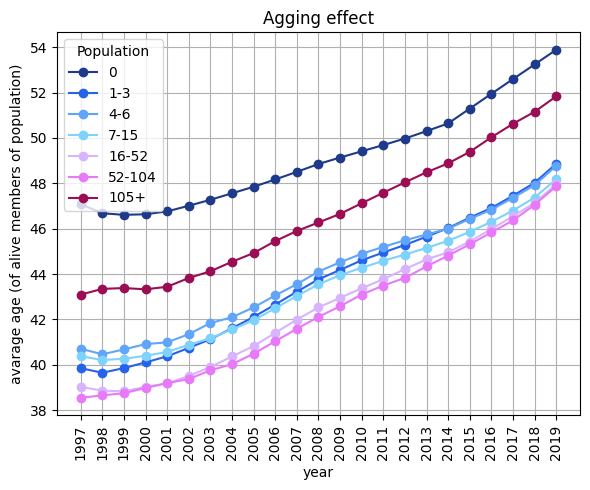

In [10]:
# analyze aging effect
plt.figure(figsize=(6, 5))
labels = {0: '0', 1: '1-3', 2: '4-6', 3: '7-15', 4: '16-52', 5: '52-104', 6: '105+'}
colors = {0: '#1E3A8A', 1: '#2563EB', 2: '#60A5FA', 3: '#7DD3FC', 4: '#D8B4FE', 5: '#E879F9', 6: '#9B0D54'}

for population in populations:
    plt.plot(age_avr.index, age_avr[population], marker='o', label=labels[population], color=colors[population])

plt.title('Agging effect')
plt.xlabel('year')
plt.ylabel('avarage age (of alive members of population)')
plt.xticks(smr_alch5.index, rotation=90)  
plt.legend(title='Population')
plt.grid()
plt.tight_layout()
plt.savefig('agging_alch5.jpg', format='jpg')
plt.show()

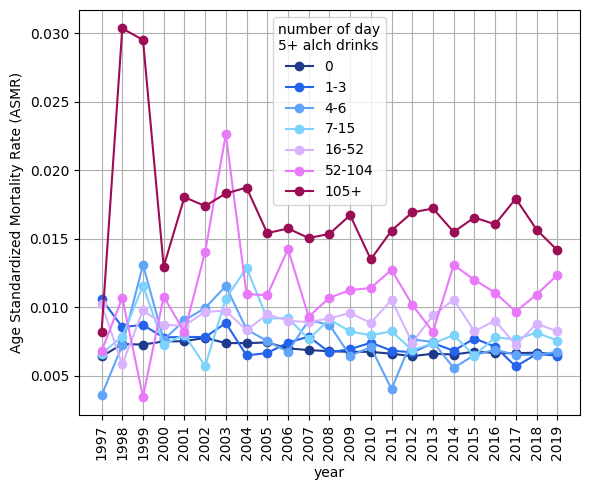

In [11]:
plt.figure(figsize=(6, 5))
for population in populations:
    plt.plot(smr_alch5.index, smr_alch5[population], marker='o', label=labels[population], color=colors[population])

plt.xlabel('year')
plt.ylabel('Age Standardized Mortality Rate (ASMR)')
plt.xticks(smr_alch5.index, rotation=90)  
plt.legend(title='number of day\n5+ alch drinks')
plt.grid()
plt.tight_layout()
plt.savefig('smr_alch5.jpg', format='jpg')
plt.show()

In [12]:
# compute average per population
smr_mean = smr_alch5.mean()

# define custom labels for x-axis
label_list = [labels[i] for i in range(len(labels))]
color_list = [colors[i] for i in range(len(colors))]

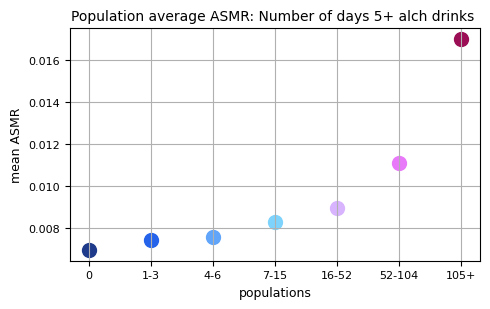

In [13]:
# --- plot ---
plt.figure(figsize=(5, 3.2))

# loop through the points and color them
for i, (x, y) in enumerate(zip(smr_mean.index, smr_mean.values)):
    plt.scatter(x, y, color=color_list[i], s=100)
    
plt.title('Population average ASMR: Number of days 5+ alch drinks ', fontsize=10)
plt.xlabel('populations', fontsize=9)
plt.ylabel('mean ASMR', fontsize=9)
plt.xticks(smr_mean.index, label_list, rotation=0, fontsize=8)  
plt.yticks(fontsize=8)
plt.tight_layout()  
plt.grid(True)  
plt.savefig('avr_amr_alch5.jpg', format='jpg')
plt.show()